# Sentiment Analysis on Amazon Product Reviews

## Objective

The objective of this project is to analyze customer reviews and classify them into positive and negative sentiments using Natural Language Processing (NLP) and Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
df = pd.read_csv("amazon.csv")

In [3]:
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   int64  
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(2), int64(7), object(3)
memory usage: 460.9+ KB


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
reviewerName,1
overall,0
reviewText,1
reviewTime,0
day_diff,0
helpful_yes,0
helpful_no,0
total_vote,0
score_pos_neg_diff,0


In [6]:
df = df[["reviewText", "overall"]]
df.head()

,reviewText,overall
0,No issues.,4
1,"Purchased this for my device, it worked as adv...",5
2,it works as expected. I should have sprung for...,4
3,This think has worked out great.Had a diff. br...,5
4,"Bought it with Retail Packaging, arrived legit...",5


In [7]:
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score <= 2:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["overall"].apply(sentiment)

In [8]:
df[["reviewText", "overall", "Sentiment"]].head()

,reviewText,overall,Sentiment
0,No issues.,4,Positive
1,"Purchased this for my device, it worked as adv...",5,Positive
2,it works as expected. I should have sprung for...,4,Positive
3,This think has worked out great.Had a diff. br...,5,Positive
4,"Bought it with Retail Packaging, arrived legit...",5,Positive


In [9]:
df = df[df["Sentiment"] != "Neutral"]

In [10]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,4449
Negative,324


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X = tfidf.fit_transform(df["reviewText"].astype(str))
y = df["Sentiment"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9350785340314136


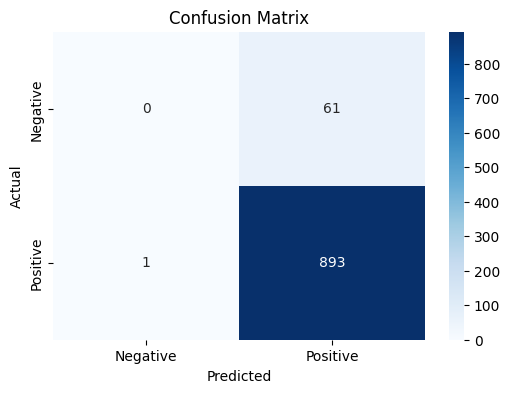

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Observation

The sentiment analysis model was evaluated using a classification report and confusion matrix. The report provides precision, recall, F1-score, and overall accuracy for each sentiment class. The confusion matrix illustrates the number of correct and incorrect predictions made by the model.

# Conclusion

The sentiment analysis model was successfully built using TF-IDF vectorization and the Multinomial Naive Bayes algorithm. The model was trained to classify customer reviews into positive and negative sentiments and evaluated using accuracy, a classification report, and a confusion matrix. The results demonstrate the effectiveness of machine learning techniques for analyzing customer feedback.